<a href="https://colab.research.google.com/github/marcheanin/hf_llm_course/blob/main/03_llm_fine-tuning/HF_LLM_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Intro

В этой главе будут рассмотрены следующие пункты:

- Как подготовить большой датасет для дообучения модели
- Как использовать верхнеуровневый `Trainer` API для дообучения модели с лучшими подходами
- Как написать кастомный train-цикл
- Как использовать HF Accelerate labrary для распределенного обучения
- Как применить best-practice

## Обработка данных

На Hugging Face есть не только обширная библиотека моделей, но и датасетов. Посморим на простую команду, которую предоставляет HF для загрузки датасетов - загрузим MRPC датасет:

In [ ]:
from datasets import load_dataset

raw_datasets = load_dataset("glue", "mrpc")
raw_datasets

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mrpc/train-00000-of-00001.parquet:   0%|          | 0.00/649k [00:00<?, ?B/s]

mrpc/validation-00000-of-00001.parquet:   0%|          | 0.00/75.7k [00:00<?, ?B/s]

mrpc/test-00000-of-00001.parquet:   0%|          | 0.00/308k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

Видим три сплита данных - `DatasetDict`. Он содержит триплеты с парами предложений, целевой меткой и индексами.

Можем получить пару предложений по индексу

In [ ]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

Так же можно, получить набор доступных фичей этого датасета

In [ ]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

Для препроцессинга сообщений возьмем токенайзер и токенезируем предложения для передачи в модель.



In [ ]:
from transformers import AutoTokenizer

checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["sentence1"], examples["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

Модель ожидает ввод типа `[CLS] sentence1 [SEP] sentence2 [SEP]`, такая маска и задается.

Также, метод описанный выше через `map` сохраняет ту же структуру словаря, какую мы и ожидаем.

In [ ]:
tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

#### Dynamyc Padding

Функция для сбора батча воедино называется `collate function`. Ее можно передать как аргумент при формировании `DataLoader`. Стандартная функция не сможет корректно предобработать последовательности разной длины, поэтому сформируем свою с динамическим паддингом.



В библиотеке transformers уже есть функция, которая превращает токенайзер в collate-функцию

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Для тестирования, наберем предложений разной длины из нашего датасета и посмотрим, как эта функция собирает батч:

In [ ]:
samples = tokenized_datasets["train"][:8]
samples = {k: v for k, v in samples.items() if k not in ["idx", "sentence1", "sentence2"]}
[len(x) for x in samples["input_ids"]]

[50, 59, 47, 67, 59, 50, 62, 32]

In [ ]:
batch = data_collator(samples)
{k: v.shape for k, v in batch.items()}

{'input_ids': torch.Size([8, 67]),
 'token_type_ids': torch.Size([8, 67]),
 'attention_mask': torch.Size([8, 67]),
 'labels': torch.Size([8])}

Всё работает как надо, последовательности одной длины.

## Fine-tuning model with the Trainer API

Библиотека трансформеров имеет класс Trainer который помогает проводить fine-tuning любых предобученных моделей при передаче в него датасета, при этом используя актуальные техники такого дообучения.

Дообучение сопряжено с работой с тензорами, которые оптимизированы по GPU, на CPU проводить обучение не рекомендуется.

Вернемся к тому, что мы уже сделали. Напишем это коротким фрагментом

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", "mrpc")

checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenizer_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenizer_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mrpc/train-00000-of-00001.parquet:   0%|          | 0.00/649k [00:00<?, ?B/s]

mrpc/validation-00000-of-00001.parquet:   0%|          | 0.00/75.7k [00:00<?, ?B/s]

mrpc/test-00000-of-00001.parquet:   0%|          | 0.00/308k [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

#### Обучение

В начале обучения нужно сформировать конфиг с настройками обучения

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments("test-trainer")

Теперь определим модель специально под нашу задачу работы с двумя предложениями

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Теперь соберем всё вместе в Trainer

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
)

Запустим обучение

In [ ]:
trainer.train()

Step,Training Loss
500,0.525440
1000,0.276617


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1377, training_loss=0.32730564624395764, metrics={'train_runtime': 225.0017, 'train_samples_per_second': 48.906, 'train_steps_per_second': 6.12, 'total_flos': 405114969714960.0, 'train_loss': 0.32730564624395764, 'epoch': 3.0})

#### Оценка полученной модели

Можно добавить к обучению свою функцию подсчета метрик - `compute_metrics()`. Функция должна получать на вход `EvalPrediction` объект - это named_tuple с двумя полями - predictions (логиты выходов) и labed_ids (истинные метки)

Чтобы получить предсказания модели, сделаем так:

In [ ]:
predictions = trainer.predict(tokenized_datasets["validation"])
print(predictions.predictions.shape, predictions.label_ids.shape)

(408, 2) (408,)


Выход такого предсказания - tuple с тремя полями - predictions, label_ids, metrics. Метрики сейчас содержат только loss и время на предикт, тотал, в среднем (по сути это метаданные).

(408? 2): 408 - кол-во примеров в val наборе, 2 - кол-во классов. Первый столбец - score для класса 0, второй - score для класса 1.

(408,) - массив целых чисел 0 или 1 - истинные метки.

Теперь преобразуем логиты в предсказанные классы.

In [ ]:
import numpy as np

preds = np.argmax(predictions.predictions, axis=-1)

In [21]:
import numpy as np

Наконец мы можем сравнить полученные метки с целевыми, формируя метрики

In [ ]:
!pip install evaluate
import evaluate

metric = evaluate.load("glue", "mrpc")
metric.compute(predictions=preds, references=predictions.label_ids)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


{'accuracy': 0.8529411764705882, 'f1': 0.8969072164948454}

Теперь можно обернуть это в compute_metrics фукнцию

In [13]:
def compute_metrics(eval_preds):
    metric = evaluate.load("glue", "mrpc")
    # eval_preds - это объект EvalPrediction, который имеет атрибуты .predictions и .label_ids
    predictions = np.argmax(eval_preds.predictions, axis=-1)
    return metric.compute(predictions=predictions, references=eval_preds.label_ids)

И теперь ее можно передать также в triner

In [ ]:
training_args = TrainingArguments("test-trainer", eval_strategy="epoch")
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.154870
1000,0.079273


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1377, training_loss=0.09864020503424352, metrics={'train_runtime': 216.7338, 'train_samples_per_second': 50.772, 'train_steps_per_second': 6.353, 'total_flos': 405114969714960.0, 'train_loss': 0.09864020503424352, 'epoch': 3.0})

Теперь мы получим результат обучения уже с метриками.

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 1.0290577411651611, 'eval_runtime': 2.0582, 'eval_samples_per_second': 198.232, 'eval_steps_per_second': 24.779, 'epoch': 3.0}


Так как `trainer.evaluate()` не включил `accuracy` и `f1` в свой результат, мы можем вручную получить предсказания и затем применить нашу функцию `compute_metrics`.

In [ ]:
# Получаем предсказания модели на валидационном наборе
validation_predictions = trainer.predict(tokenized_datasets["validation"])

# Применяем нашу функцию compute_metrics к этим предсказаниям
# Теперь передаем весь объект validation_predictions, который является EvalPrediction
calculated_metrics = compute_metrics(validation_predictions)

print("Рассчитанные метрики:")
print(calculated_metrics)

Рассчитанные метрики:
{'accuracy': 0.8480392156862745, 'f1': 0.8945578231292517}


## Полный цикл обучения

Теперь напишем цикл обучения без использования Trainer. Снова напишем базовые токенизации для начала

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", "mrpc")
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)


tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mrpc/train-00000-of-00001.parquet:   0%|          | 0.00/649k [00:00<?, ?B/s]

mrpc/validation-00000-of-00001.parquet:   0%|          | 0.00/75.7k [00:00<?, ?B/s]

mrpc/test-00000-of-00001.parquet:   0%|          | 0.00/308k [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

Для начала нужно определить DataLoader, который будет передавать данные в обучение, формируя батчи. При этом, нужно подготовить тренировочный датасет, удалив из него ненужные для обучения колонки, переименовать некоторые из них в ожидаемые названия.

In [4]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

Теперь определяем DataLoaders

In [5]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(tokenized_datasets["train"], shuffle=True, batch_size=8, collate_fn=data_collator)
eval_dataloader = DataLoader(tokenized_datasets["validation"], batch_size=8, collate_fn=data_collator)

In [6]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([8]),
 'input_ids': torch.Size([8, 61]),
 'token_type_ids': torch.Size([8, 61]),
 'attention_mask': torch.Size([8, 61])}

Теперь определяем ту же модель, что и раньше

In [7]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7246, grad_fn=<NllLossBackward0>) torch.Size([8, 2])


Для обучения осталось определить оптимизатор и learning rate scheduler.

In [19]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

Теперь нам нужно определить lr_scheduler. Он решает как менять learing rate во время обучения на основе его прогресса.

В текущем примере будем использовать линейное уменьление lr, чтобы вначале сходиться быстрее, а в конце - не перескочить минимум.

LR(t) = initial_LR * (1 - t / total_steps)

```
LR
 ↑
5e-5 ┤●●●●●●●●
     │         ●●●●●●
     │              ●●●
     │                 ●
  0  └───────────────────→ шаги
     0                 1377

In [ ]:
from transformers import get_scheduler

num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)
print(num_training_steps)

1377


Определяем доступный ускоритель и переводим модель в него

In [16]:
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
device

device(type='cuda')

Теперь добавим `tqdm` библиотеку, чтобы интерактивно видеть прогресс обучения.

In [10]:
from tqdm.auto import tqdm

In [ ]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

  0%|          | 0/1377 [00:00<?, ?it/s]

Это обучение работает, однако мы не собираем в процессе никакие метрики обучения. Чтобы его добавить, напишем evaluation_loop.

В следующем методе мы будем считать метрики почти также, как и в compute_metrics, однако будем собирать и аккумулировать информацию по батчам аддитивно - именно на это рассчитан наш текущий даталоадер и в целом работа с датасетом.

In [17]:
!pip install evaluate
import evaluate

metric = evaluate.load("glue", "mrpc")
model.eval()
for batch in eval_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    metric.add_batch(predictions=predictions, references=batch["labels"])

metric.compute()

{'accuracy': 0.7352941176470589, 'f1': 0.8241042345276873}

#### Accelerate

Это мощная прокачка нашего обучающего процесса за счет распределения вычислений на несколько ускорителей, mixed precision, автоматическое определение device и т д.

In [22]:
from accelerate import Accelerator
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, get_scheduler

accelerator = Accelerator()

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
optimizer = AdamW(model.parameters(), lr=3e-5)

train_dl, eval_dl, model, optimizer = accelerator.prepare(
    train_dataloader, eval_dataloader, model, optimizer
)

num_epochs = 3
num_training_steps = num_epochs * len(train_dl)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

progress_bar = tqdm(range(num_training_steps))

#model.train()
# for epoch in range(num_epochs):
#     for batch in train_dl:
#         outputs = model(**batch)
#         loss = outputs.loss
#         accelerator.backward(loss)

#         optimizer.step()
#         lr_scheduler.step()
#         optimizer.zero_grad()
#         progress_bar.update(1)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/1377 [00:00<?, ?it/s]

Теперь соберем в одном месте все best practices:

- Оценка модели должна происходить на расширенном наборе метрик, не только на accuracy
- Очень важен тюнинг гиперпараметров. Это можно делать автоматически, используя фреймворки типа Optuna или Ray Tune
- Метрики и остальные показатели важно отслеживать и выводить уже в процессе обучения
- Можно поделиться обученной моделью через HF Community
- Для больших моделей стоит рассмотреть техники parameter-efficient fine-tuning (LORA, AdaLORA), или квантизацию

## Кривые обучения

Обычно двух типов:
1) loss - падает с течением обучения, вначале большой
2) Метрики качества - растут

В trainer API можно задать построение кривых обучения

In [23]:
# Example of tracking loss during training with the Trainer
from transformers import Trainer, TrainingArguments
import wandb

# Initialize Weights & Biases for experiment tracking
wandb.init(project="transformer-fine-tuning", name="bert-mrpc-analysis")

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=50,
    save_steps=100,
    logging_steps=10,  # Log metrics every 10 steps
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    report_to="wandb",  # Send logs to Weights & Biases
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# Train and automatically log metrics
trainer.train()

train/epoch,▁▃▅▆█
train/global_step,▁▃▅▆█
train/grad_norm,▁▁▁▁█
train/learning_rate,█▆▄▃▁
train/loss,█▄▁▃▅
train/epoch,0.21739
train/global_step,50
train/grad_norm,19.84894
train/learning_rate,5e-05
train/loss,0.44675


Step,Training Loss,Validation Loss,Accuracy,F1
50,0.622400,0.550836,0.725490,0.818770
100,0.513403,0.510338,0.767157,0.848000
150,0.500007,0.443634,0.828431,0.885621
200,0.408066,0.384095,0.850490,0.895369
250,0.268667,0.382014,0.850490,0.890485
300,0.247499,0.445885,0.833333,0.887417
350,0.214505,0.412297,0.830882,0.876122
400,0.188275,0.501741,0.850490,0.899174
450,0.321814,0.359637,0.860294,0.896926
500,0.202476,0.559322,0.852941,0.895833


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=690, training_loss=0.31349221731441607, metrics={'train_runtime': 330.1309, 'train_samples_per_second': 33.332, 'train_steps_per_second': 2.09, 'total_flos': 428577075854640.0, 'train_loss': 0.31349221731441607, 'epoch': 3.0})

#### Сходимость

Сходимость наступает, когда модель стабилизируется, loss больше не падает

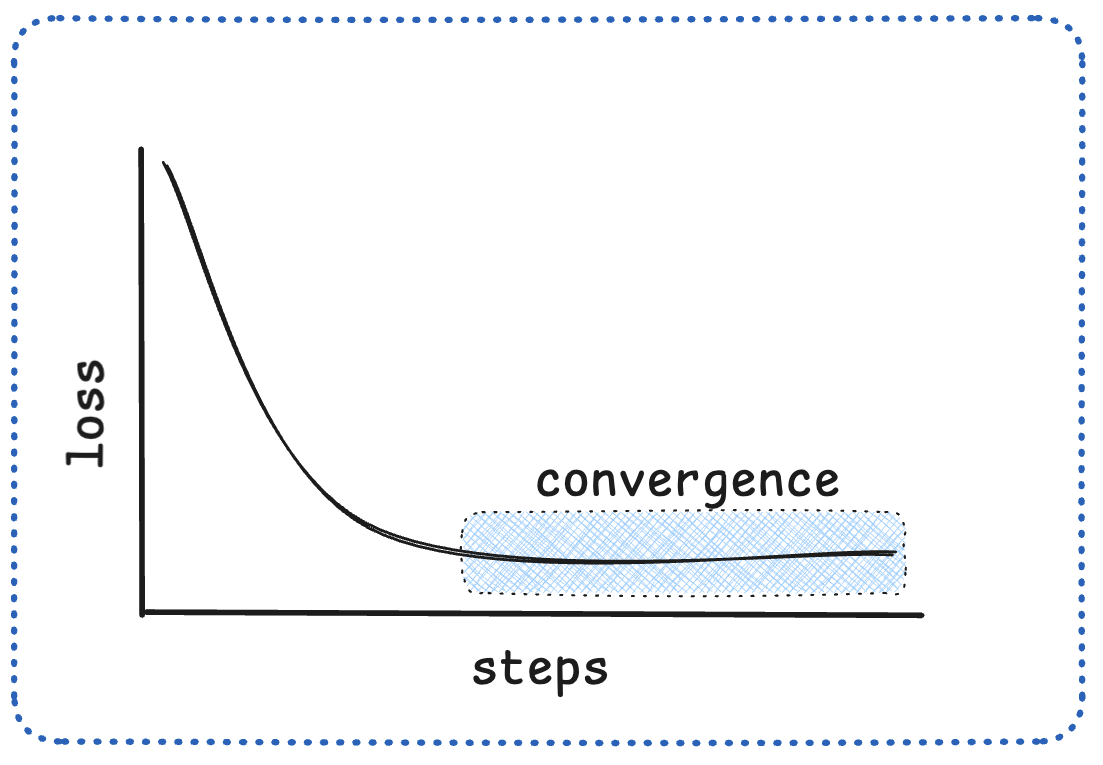

#### Виды кривых обучения

Кривые обучения здорового человека:
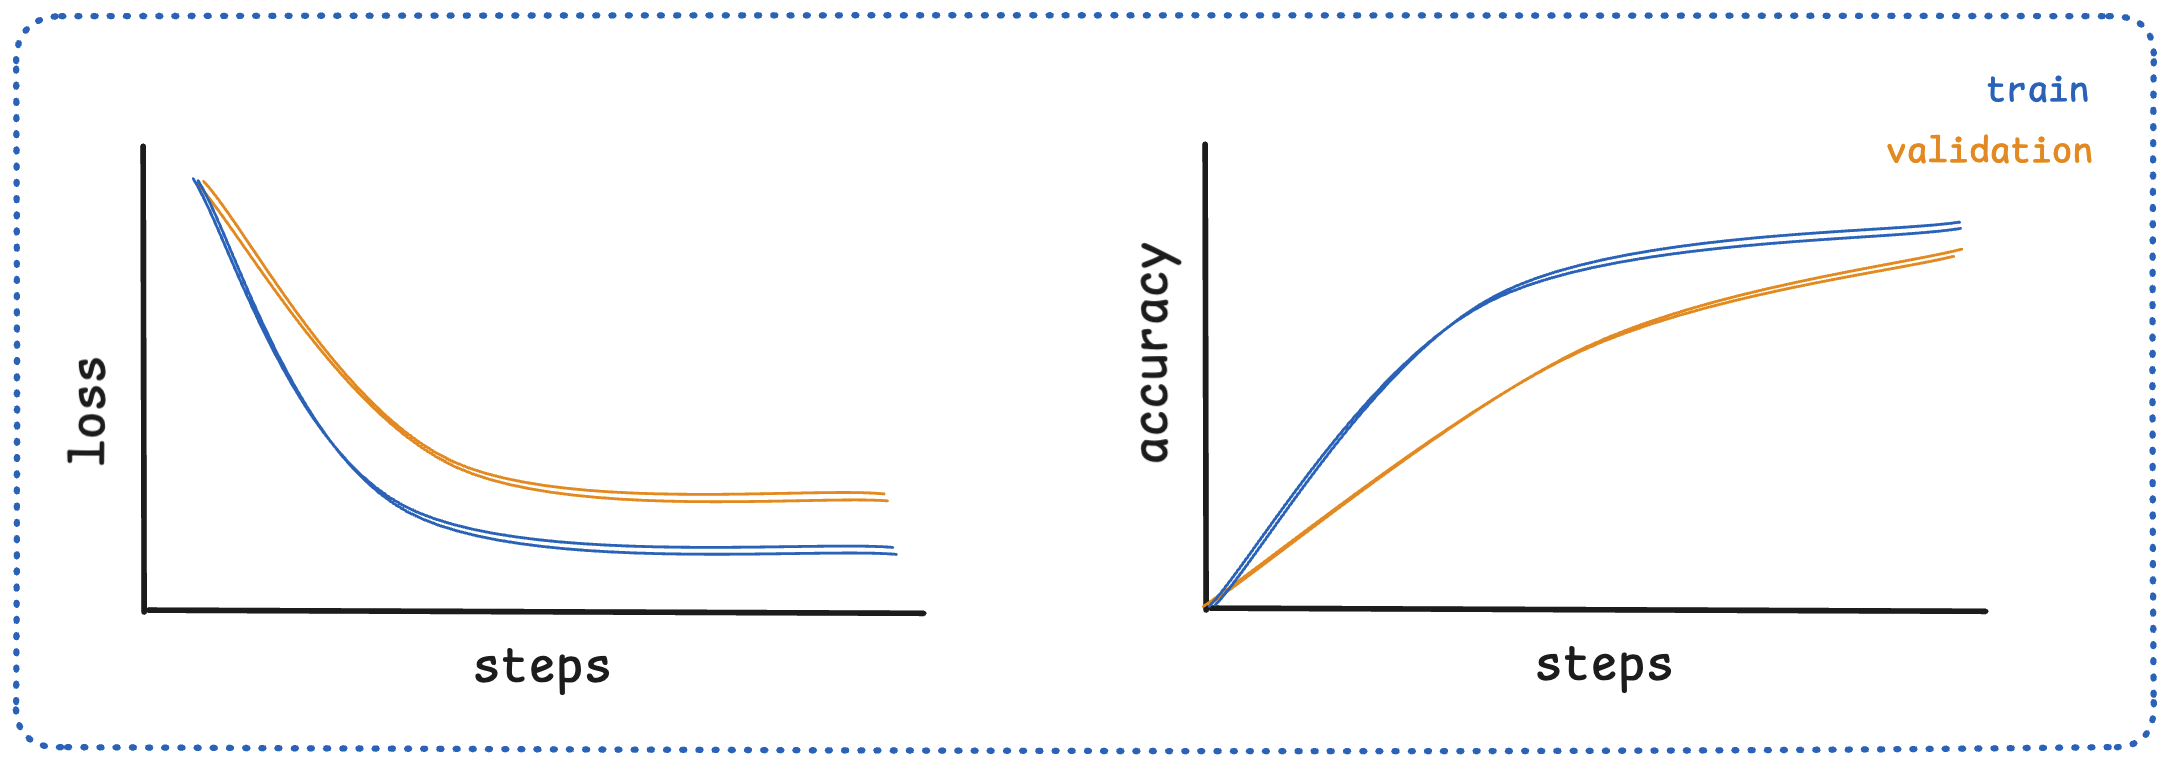